In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
import numpy as np   

In [6]:
%matplotlib inline  

In [27]:
df = pd.read_csv('FuelConsumptionCo2.csv')

In [8]:
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
676,2014,LEXUS,RX 450h AWD,SUV - SMALL,3.5,6,AV6,Z,7.9,8.6,8.2,34,189
611,2014,KIA,FORTE KOUP,COMPACT,2.0,4,A6,X,9.6,7.0,8.4,34,193
795,2014,MINI,COOPER S CONVERTIBLE,MINICOMPACT,1.6,4,M6,Z,9.1,6.7,8.0,35,184
522,2014,HYUNDAI,VELOSTER,COMPACT,1.6,4,AM6,X,8.6,6.6,7.7,37,177
810,2014,MINI,JOHN COOPER WORKS COUPE,TWO-SEATER,1.6,4,A6,Z,9.3,7.0,8.3,34,191


In [9]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [10]:
df.corr(numeric_only=True)['CO2EMISSIONS']

MODELYEAR                        NaN
ENGINESIZE                  0.874154
CYLINDERS                   0.849685
FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_HWY         0.861748
FUELCONSUMPTION_COMB        0.892129
FUELCONSUMPTION_COMB_MPG   -0.906394
CO2EMISSIONS                1.000000
Name: CO2EMISSIONS, dtype: float64

In [11]:
cdf = df[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB","CO2EMISSIONS"]]

In [12]:
cdf.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
667,3.5,6,10.6,244
481,2.4,4,7.9,182
942,2.0,4,8.5,196
100,3.0,6,7.9,213
751,5.5,8,13.5,310


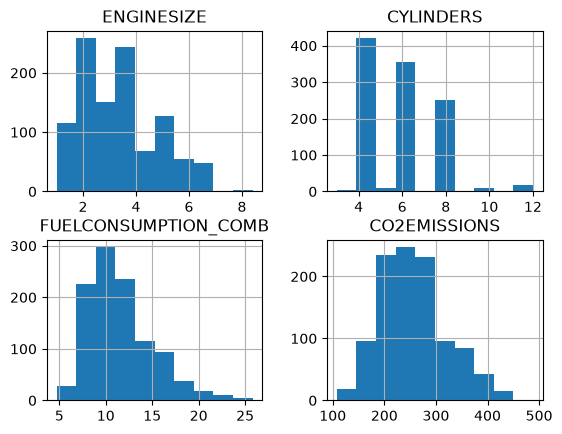

In [15]:
cdf.hist()
plt.show()

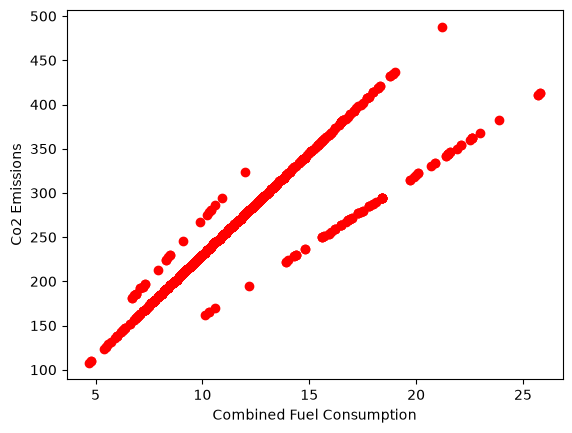

In [20]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,cdf.CO2EMISSIONS,color='red')
plt.xlabel("Combined Fuel Consumption")
plt.ylabel("Co2 Emissions")
plt.show()

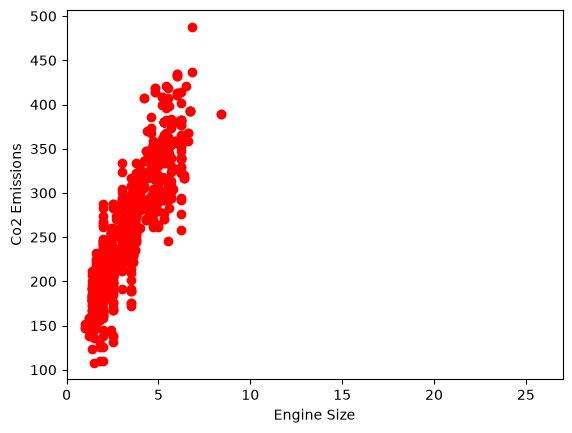

In [25]:
plt.scatter(cdf.ENGINESIZE,cdf.CO2EMISSIONS,color='red')
plt.xlabel("Engine Size")
plt.ylabel("Co2 Emissions")
plt.xlim(0,27)
plt.show()

In [30]:
x = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
np.shape(x_train)

(853,)

In [39]:
type(x_train)

numpy.ndarray

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

x_train = x_train.reshape(-1, 1)

model.fit(x_train, y_train)

print("Coefficient:", model.coef_)
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: [38.99297872]
Coefficient: 38.99297872443407
Intercept: 126.28970217408724


In [46]:
new_engine_size = [[3.0]]

predicted_co2 = model.predict(new_engine_size)

print("Predicted CO2 Emission:", predicted_co2[0])

Predicted CO2 Emission: 243.26863834738944


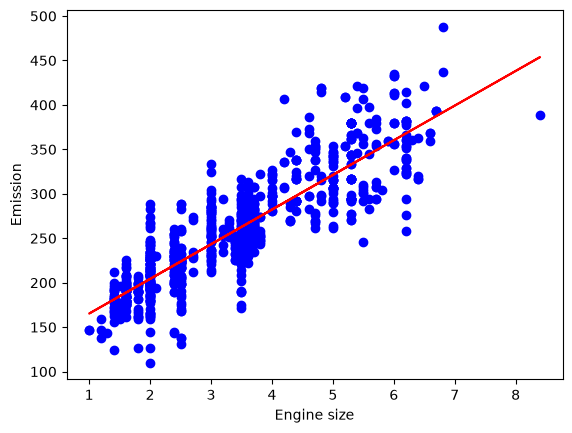

In [48]:
plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, model.coef_ * x_train + model.intercept_, color='red')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

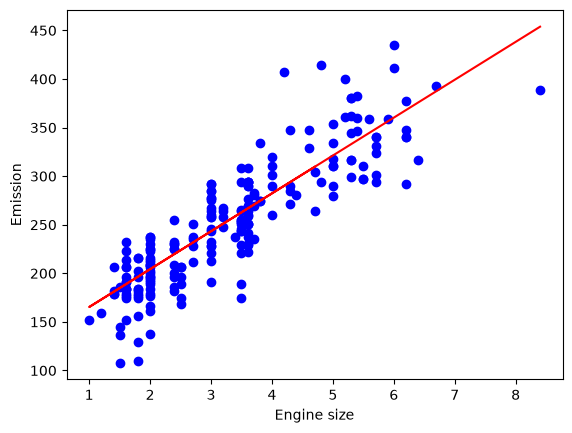

In [49]:
plt.scatter(x_test, y_test, color='blue')
plt.plot(x_test, model.coef_ * x_test + model.intercept_, color='red')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x_test = x_test.reshape(-1, 1)

y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 24.09725741170784
Mean Squared Error: 985.9381692274999
Root Mean Squared Error: 31.399652374309813
R2 Score: 0.7615595731934373
